# Phase 4: Machine Learning Model Selection & Training

In [1]:
# Cell 1: Import libraries
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load the engineered data from Phase 5
X_train = pd.read_csv('../data/X_train.csv')
X_test = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv')
y_test = pd.read_csv('../data/y_test.csv')

# y_train and y_test are loaded as DataFrames, let's convert them to 1D arrays (Series) for the model
y_train = y_train.squeeze()
y_test = y_test.squeeze()

print("Training and Testing data loaded successfully!")

Training and Testing data loaded successfully!


In [2]:
# Cell 2: Initialize & Train the Random Forest Model
print("Training the Random Forest model... (This might take a few seconds)")

# Initialize the model with 100 decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model
rf_model.fit(X_train, y_train)

print("Model training completed successfully! 🚀")

Training the Random Forest model... (This might take a few seconds)
Model training completed successfully! 🚀


In [3]:
# Cell 3: Model Prediction & Evaluation
# Ask the model to predict the answers for the test data
y_pred = rf_model.predict(X_test)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

# Detailed Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 50.81%

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.53      0.52     20359
           1       0.50      0.48      0.49     20043

    accuracy                           0.51     40402
   macro avg       0.51      0.51      0.51     40402
weighted avg       0.51      0.51      0.51     40402



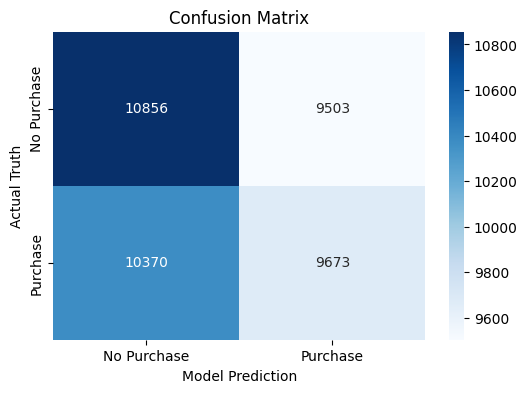

In [4]:
# Cell 4: Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Purchase', 'Purchase'], 
            yticklabels=['No Purchase', 'Purchase'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Truth')
plt.xlabel('Model Prediction')
plt.show()

In [5]:
# Cell 5: Save the trained model for Deployment
model_path = '../src/random_forest_model.pkl'
joblib.dump(rf_model, model_path)

print(f"Trained model saved successfully to {model_path}!")

Trained model saved successfully to ../src/random_forest_model.pkl!
